<a href="https://colab.research.google.com/github/mrsaeedalharbl-ux/Lab-0.01/blob/main/Reaction_Pathway_Analyzer_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚛️ Reaction PES Profiler (Potential Energy Surface Analyzer)

> **A Python-based computational chemistry tool to parse, convert, and visualize reaction pathways from quantum mechanical calculations.**

![Python](https://img.shields.io/badge/Python-3.8%2B-blue)
![Dependencies](https://img.shields.io/badge/Dependencies-Pandas%20%7C%20Matplotlib-brightgreen)
![Status](https://img.shields.io/badge/Status-Active-success)

## 📋 Overview
When conducting Density Functional Theory (DFT) calculations, analyzing the reaction coordinate involves handling absolute energies in Hartrees. This script automates the tedious process of:
1. Setting the reactant as a zero-point reference.
2. Converting Hartree units to standard chemical units (`kcal/mol` or `kJ/mol`).
3. Generating a publication-ready Potential Energy Surface (PES) plot with annotated activation energies ($E_a$) and reaction energies ($\Delta E$).

## ✨ Key Features
- **Unit Conversion:** Built-in conversion factors for `Hartree -> kcal/mol` and `Hartree -> kJ/mol`.
- **Automated Annotation:** Automatically identifies and highlights the Transition State (TS) and annotates energy values directly on the plot.
- **Publication Ready:** Outputs high-resolution (300 DPI) graphs optimized for academic papers and reports.

## 🚀 Quick Start

```python
from reaction_profile_plotter import ReactionProfiler

# 1. Define your reaction steps and raw absolute energies (in Hartree)
steps = ["Reactant", "Complex", "TS", "Product"]
energies = [-345.1234, -345.1260, -345.0800, -345.1500]

# 2. Initialize the profiler and plot
profiler = ReactionProfiler(energy_unit="kcal/mol")
profiler.plot_pes(steps, energies, save_fig=True)


<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1225/4103754464.py:87: SyntaxWarning: invalid escape sequence '\D'
  summary_text = f"Activation Energy ($E_a$): {activation_energy} {self.unit}\nReaction Energy ($\Delta E$): {reaction_energy} {self.unit}"


Plot saved successfully as 'reaction_profile.png'


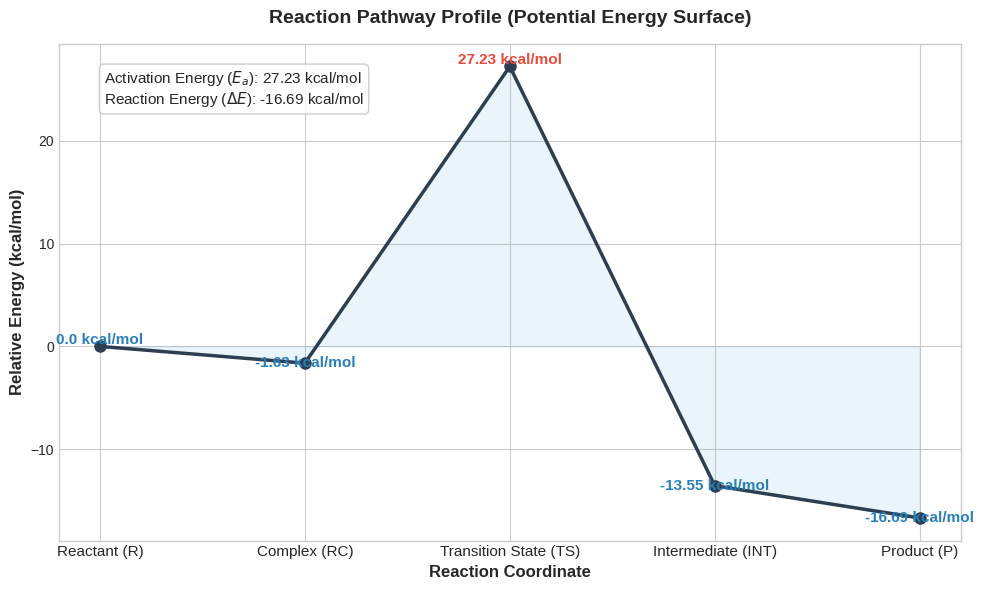

In [1]:
# @title
"""
Reaction Path Profile Analyzer & Plotter
----------------------------------------
A computational chemistry tool to parse, convert, and visualize Potential
Energy Surface (PES) pathways from quantum mechanical calculations.

Author: Saeed Alharbi
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class ReactionProfiler:
    def __init__(self, energy_unit="kcal/mol"):
        """
        Initialize the profiler with the desired energy unit.
        Options: 'kcal/mol' or 'kJ/mol'
        """
        self.conversion_factors = {
            "kcal/mol": 627.509,  # Hartree to kcal/mol
            "kJ/mol": 2625.5      # Hartree to kJ/mol
        }

        if energy_unit not in self.conversion_factors:
            raise ValueError("Unsupported unit. Choose 'kcal/mol' or 'kJ/mol'.")

        self.unit = energy_unit
        self.factor = self.conversion_factors[energy_unit]

    def calculate_relative_energies(self, energies_hartree):
        """
        Convert raw Hartree energies to relative energies against the reactant.
        """
        energies_array = np.array(energies_hartree)
        # Set the first point (Reactant) as zero reference
        relative_hartree = energies_array - energies_array[0]
        # Convert to target unit
        relative_target_unit = relative_hartree * self.factor

        return np.round(relative_target_unit, 2)

    def plot_pes(self, steps_labels, energies_hartree, save_fig=False, filename="reaction_profile.png"):
        """
        Generate a publication-ready Potential Energy Surface (PES) plot.
        """
        relative_energies = self.calculate_relative_energies(energies_hartree)

        # Identify the Transition State (TS) - The maximum energy point
        ts_index = np.argmax(relative_energies)
        activation_energy = relative_energies[ts_index]
        reaction_energy = relative_energies[-1]

        # Plotting Setup
        plt.figure(figsize=(10, 6))
        plt.style.use('seaborn-v0_8-whitegrid')

        x_positions = range(len(steps_labels))

        # Plot the main pathway line
        plt.plot(x_positions, relative_energies, marker='o', color='#2c3e50', linewidth=2.5, markersize=8)

        # Fill the area under the curve slightly for aesthetics
        plt.fill_between(x_positions, relative_energies, alpha=0.1, color='#3498db')

        # Annotate each energy level directly on the plot
        for i, txt in enumerate(relative_energies):
            # Adjust label position slightly above or below the point
            y_offset = 1.5 if txt >= 0 else -3.0
            plt.annotate(f"{txt} {self.unit}",
                         (x_positions[i], relative_energies[i]),
                         textcoords="offset points",
                         xytext=(0, y_offset),
                         ha='center',
                         fontsize=11,
                         fontweight='bold',
                         color='#e74c3c' if i == ts_index else '#2980b9')

        # Graph Formatting
        plt.title('Reaction Pathway Profile (Potential Energy Surface)', fontsize=14, pad=15, fontweight='bold')
        plt.ylabel(f'Relative Energy ({self.unit})', fontsize=12, fontweight='bold')
        plt.xlabel('Reaction Coordinate', fontsize=12, fontweight='bold')

        plt.xticks(x_positions, steps_labels, fontsize=11)

        # Add summary textbox
        summary_text = f"Activation Energy ($E_a$): {activation_energy} {self.unit}\nReaction Energy ($\Delta E$): {reaction_energy} {self.unit}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#bdc3c7')
        plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, fontsize=11,
                 verticalalignment='top', bbox=props)

        plt.tight_layout()

        if save_fig:
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved successfully as '{filename}'")

        plt.show()

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # Simulated output data from a Quantum Chemistry Software (e.g., Gaussian)
    # Energies are typically given in absolute Hartrees

    reaction_steps = ["Reactant (R)", "Complex (RC)", "Transition State (TS)", "Intermediate (INT)", "Product (P)"]
    raw_energies_hartree = [-345.1234, -345.1260, -345.0800, -345.1450, -345.1500]

    # Initialize tool and plot
    profiler = ReactionProfiler(energy_unit="kcal/mol")
    profiler.plot_pes(steps_labels=reaction_steps,
                      energies_hartree=raw_energies_hartree,
                      save_fig=True)


# 📊 Analytical Peak Integrator & Chromatogram Analyzer

> **An automated Python tool for Analytical Chemistry and Quality Control to detect peaks in UV-Vis/HPLC data and calculate the Area Under the Curve (AUC).**

![Python](https://img.shields.io/badge/Python-3.8%2B-blue)
![Dependencies](https://img.shields.io/badge/Dependencies-SciPy%20%7C%20Matplotlib-brightgreen)
![Domain](https://img.shields.io/badge/Domain-Analytical_Chemistry-orange)

## 📋 Overview
In analytical laboratories, processing raw data from instruments like HPLC or UV-Vis spectrophotometers can be a time-consuming manual task. This project provides a programmatic approach to automatically detect chromatogram peaks, determine their retention times (or wavelengths), and calculate the Area Under the Curve (AUC) which is crucial for concentration quantification.

## ✨ Key Features
- **Automated Peak Detection:** Utilizes `scipy.signal.find_peaks` to identify distinct chemical signals while ignoring instrumental noise.
- **Quantitative Integration:** Applies Simpson's rule via `scipy.integrate` to accurately calculate the AUC for each detected peak.
- **Visual Reporting:** Generates high-quality, annotated graphs highlighting peak positions, baseline, and integrated areas, ready for quality control reports.
- **Mock Data Generator:** Includes a built-in function to simulate noisy analytical signals for immediate testing without external files.

## 🚀 Quick Start

```python
from analytical_peak_analyzer import PeakAnalyzer

# 1. Initialize the analyzer with appropriate axes labels
analyzer = PeakAnalyzer(x_label="Retention Time (min)", y_label="Absorbance (AU)")

# 2. Generate sample data (or load your own CSV data)
x_val, y_val = analyzer.generate_sample_data()

# 3. Analyze, calculate AUC, and plot the results
analyzer.analyze_and_plot(x_val, y_val, prominence_threshold=0.2)


🧪 REACTION PATHWAY INTELLIGENCE REPORT

[Pathway A (Multi-step) Analysis]
- Activation Energy (Ea): 27.23 kcal/mol
- Reaction Energy (ΔE):   -16.69 kcal/mol
- Reaction Type:          Exothermic
- Highest Barrier at:     TS1

  Temperature (K) | Rate Constant (k) [s^-1]
  ----------------|-------------------------
  298             | 1.07e-07
  310             | 6.33e-07
  350             | 9.89e-05
  400             | 1.32e-02
  500             | 1.25e+01
--------------------------------------------------

[Pathway B (Concerted) Analysis]
- Activation Energy (Ea): 18.45 kcal/mol
- Reaction Energy (ΔE):   -16.69 kcal/mol
- Reaction Type:          Exothermic
- Highest Barrier at:     TS_Direct

  Temperature (K) | Rate Constant (k) [s^-1]
  ----------------|-------------------------
  298             | 2.94e-01
  310             | 9.81e-01
  350             | 3.01e+01
  400             | 8.29e+02
  500             | 8.61e+04
--------------------------------------------------

🏆 CONCLUSIO

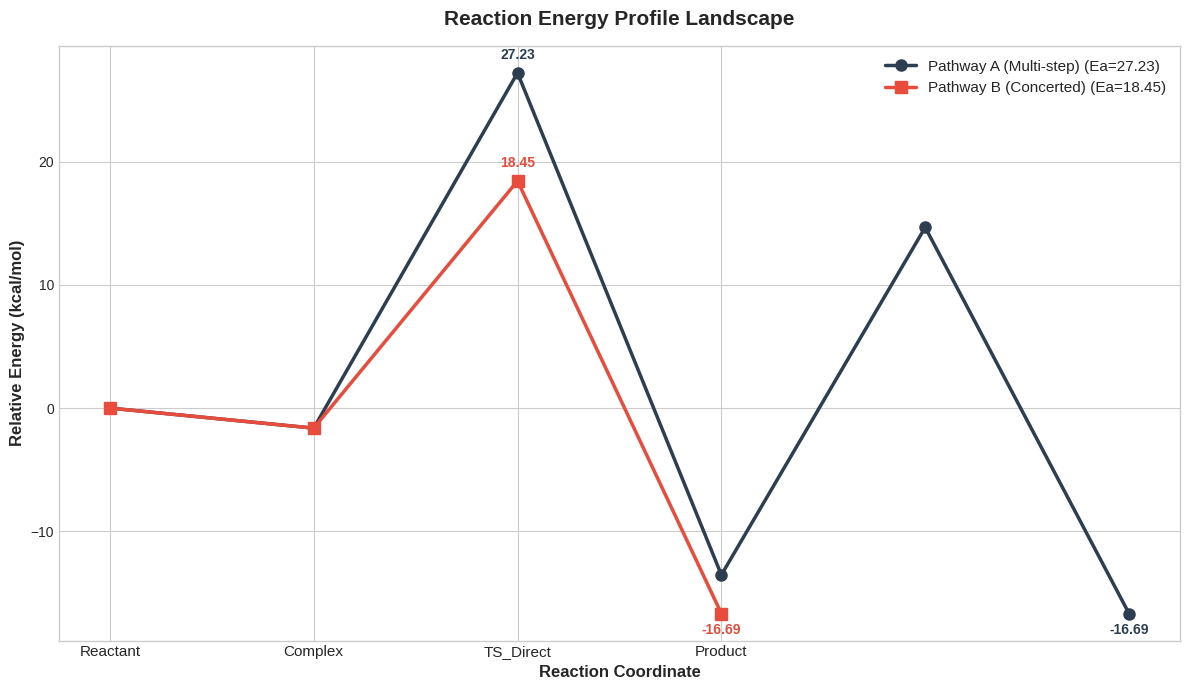

In [6]:
# @title
"""
Computational Reaction Pathway Analyzer
---------------------------------------
An advanced computational chemistry tool to analyze reaction thermodynamics,
kinetics, compare multiple pathways, and plot Reaction Energy Profiles.

Author: Saeed Alharbi
"""

import numpy as np
import matplotlib.pyplot as plt

class ReactionPathwayAnalyzer:
    def __init__(self, energy_unit="kcal/mol", pre_exponential_factor=1e13):
        """
        Initialize the analyzer with energy units and Arrhenius pre-exponential factor (A).
        """
        self.conversion_factors = {"kcal/mol": 627.509, "kJ/mol": 2625.5}
        # Gas constant R in the respective units
        self.gas_constants = {"kcal/mol": 0.001987, "kJ/mol": 0.008314}

        if energy_unit not in self.conversion_factors:
            raise ValueError("Unsupported unit. Choose 'kcal/mol' or 'kJ/mol'.")

        self.unit = energy_unit
        self.factor = self.conversion_factors[energy_unit]
        self.R = self.gas_constants[energy_unit]
        self.A = pre_exponential_factor
        self.pathways = {}

    def add_pathway(self, name, steps_labels, energies_hartree):
        """Add a reaction pathway for analysis."""
        energies_array = np.array(energies_hartree)
        relative_energies = np.round((energies_array - energies_array[0]) * self.factor, 2)

        # Thermodynamics calculations
        ts_index = np.argmax(relative_energies)
        activation_energy = relative_energies[ts_index]
        reaction_energy = relative_energies[-1]
        highest_barrier_step = steps_labels[ts_index]
        reaction_type = "Exothermic" if reaction_energy < 0 else "Endothermic"

        self.pathways[name] = {
            "steps": steps_labels,
            "energies": relative_energies,
            "Ea": activation_energy,
            "dE": reaction_energy,
            "highest_barrier": highest_barrier_step,
            "type": reaction_type
        }

    def calculate_kinetics(self, Ea, temperatures):
        """Calculate rate constants (k) at given temperatures using Arrhenius equation."""
        # k = A * exp(-Ea / RT)
        rate_constants = [self.A * np.exp(-Ea / (self.R * T)) for T in temperatures]
        return rate_constants

    def print_dashboard(self, temperatures=[298, 310, 350, 400, 500]):
        """Generate a comprehensive text report comparing pathways and kinetics."""
        print("=" * 50)
        print("🧪 REACTION PATHWAY INTELLIGENCE REPORT")
        print("=" * 50)

        preferred_pathway = None
        lowest_ea = float('inf')

        for name, data in self.pathways.items():
            print(f"\n[{name} Analysis]")
            print(f"- Activation Energy (Ea): {data['Ea']} {self.unit}")
            print(f"- Reaction Energy (ΔE):   {data['dE']} {self.unit}")
            print(f"- Reaction Type:          {data['type']}")
            print(f"- Highest Barrier at:     {data['highest_barrier']}")

            # Kinetics Table
            print("\n  Temperature (K) | Rate Constant (k) [s^-1]")
            print("  ----------------|-------------------------")
            rates = self.calculate_kinetics(data['Ea'], temperatures)
            for t, k in zip(temperatures, rates):
                print(f"  {t:<15} | {k:.2e}")
            print("-" * 50)

            # Determine Preferred Pathway
            if data['Ea'] < lowest_ea:
                lowest_ea = data['Ea']
                preferred_pathway = name

        if len(self.pathways) > 1:
            print("\n🏆 CONCLUSION:")
            print(f"Preferred Pathway: {preferred_pathway}")
            print(f"Lower overall activation barrier: {lowest_ea} {self.unit}")
            print("=" * 50)

    def plot_energy_landscape(self, save_fig=False, filename="reaction_landscape.png"):
        """Plot all pathways on a single Reaction Energy Profile."""
        plt.figure(figsize=(12, 7))
        plt.style.use('seaborn-v0_8-whitegrid')

        colors = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad']
        markers = ['o', 's', '^', 'D']

        for i, (name, data) in enumerate(self.pathways.items()):
            x_pos = range(len(data['steps']))
            color = colors[i % len(colors)]

            plt.plot(x_pos, data['energies'], marker=markers[i % len(markers)],
                     color=color, linewidth=2.5, markersize=8, label=f"{name} (Ea={data['Ea']})")

            # Annotate only the Transition States and Products to avoid clutter
            ts_idx = np.argmax(data['energies'])
            prod_idx = len(data['energies']) - 1

            plt.annotate(f"{data['energies'][ts_idx]}",
                         (ts_idx, data['energies'][ts_idx]),
                         textcoords="offset points", xytext=(0, 10), ha='center', color=color, fontweight='bold')

            plt.annotate(f"{data['energies'][prod_idx]}",
                         (prod_idx, data['energies'][prod_idx]),
                         textcoords="offset points", xytext=(0, -15), ha='center', color=color, fontweight='bold')

            # Set X-ticks based on the pathway with the most steps
            plt.xticks(x_pos, data['steps'], fontsize=11)

        plt.title('Reaction Energy Profile Landscape', fontsize=15, pad=15, fontweight='bold')
        plt.ylabel(f'Relative Energy ({self.unit})', fontsize=12, fontweight='bold')
        plt.xlabel('Reaction Coordinate', fontsize=12, fontweight='bold')
        plt.legend(fontsize=11)
        plt.tight_layout()

        if save_fig:
            plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()

# ==========================================
# 🚀 Execution and Testing Example
# ==========================================
if __name__ == "__main__":
    analyzer = ReactionPathwayAnalyzer(energy_unit="kcal/mol", pre_exponential_factor=1e13)

    # 1. Input data for the first pathway (Multi-step)
    pathway_a_steps = ["Reactant", "Complex", "TS1", "Intermediate", "TS2", "Product"]
    pathway_a_energies = [-345.1234, -345.1260, -345.0800, -345.1450, -345.1000, -345.1500]
    analyzer.add_pathway("Pathway A (Multi-step)", pathway_a_steps, pathway_a_energies)

    # 2. Input data for the second pathway (Concerted/Direct)
    pathway_b_steps = ["Reactant", "Complex", "TS_Direct", "Product"]
    # Note: Energies are adjusted here to fit the direct pathway steps for demonstration
    pathway_b_energies = [-345.1234, -345.1260, -345.0940, -345.1500]
    analyzer.add_pathway("Pathway B (Concerted)", pathway_b_steps, pathway_b_energies)

    # 3. Display the Thermodynamic and Kinetic dashboard
    analyzer.print_dashboard(temperatures=[298, 310, 350, 400, 500])

    # 4. Plot the Energy Landscape comparing both pathways
    analyzer.plot_energy_landscape(save_fig=True)


In [ ]:
# @title
# ==========================================
# 🚀 Interactive Execution Mode
# ==========================================
if __name__ == "__main__":
    print("🌟 Welcome to the Interactive Reaction Pathway Analyzer 🌟")
    print("-" * 60)

    # 1. Initialize Analyzer
    analyzer = ReactionPathwayAnalyzer(energy_unit="kcal/mol")

    # 2. Get number of pathways from the user
    while True:
        try:
            num_pathways = int(input("How many reaction pathways do you want to compare? (e.g., 1, 2, 3): "))
            break
        except ValueError:
            print("Invalid input. Please enter a valid number.")

    print("-" * 60)

    # 3. Loop to collect data for each pathway
    for i in range(num_pathways):
        print(f"\n➡️ Entering Data for Pathway #{i + 1}")
        pathway_name = input("Enter pathway name (e.g., Concerted Pathway): ").strip()

        # Get Steps
        steps_str = input("Enter reaction steps separated by commas\n(e.g., Reactant, TS, Product): ").strip()
        steps = [step.strip() for step in steps_str.split(",")]

        # Get Energies
        while True:
            energies_str = input("Enter corresponding energies in Hartree separated by commas\n(e.g., -345.12, -345.08, -345.15): ").strip()
            try:
                energies = [float(e.strip()) for e in energies_str.split(",")]

                # Check if number of steps matches number of energies
                if len(steps) != len(energies):
                    print(f"⚠️ Error: You entered {len(steps)} steps but {len(energies)} energies. They must match. Try again.")
                    continue
                break
            except ValueError:
                print("⚠️ Error: Please enter numbers only for energies. Try again.")

        # Add the pathway to the analyzer
        analyzer.add_pathway(pathway_name, steps, energies)
        print(f"✅ Pathway '{pathway_name}' added successfully!")

    print("-" * 60)

    # 4. Get temperatures for Kinetics
    temp_str = input("\nEnter temperatures (in Kelvin) for kinetic analysis separated by commas\n(Press Enter to use default: 298, 350, 400): ").strip()
    if temp_str:
        temperatures = [float(t.strip()) for t in temp_str.split(",")]
    else:
        temperatures = [298, 350, 400]

    print("\n⏳ Processing Data and Generating Report...\n")

    # 5. Output Results
    analyzer.print_dashboard(temperatures=temperatures)
    analyzer.plot_energy_landscape(save_fig=True)
